In [1]:
from test.test_langevin import get_bm, get_terms, langevin_diffusion, langevin_drift

import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
from diffrax import (
    ALIGN,
    diffeqsolve,
    Euler,
    HalfSolver,
    PIDController,
    SaveAt,
    SEA,
    ShARK,
)
from jax import config


config.update("jax_enable_x64", True)


def plot_sol(sol, dim=1):
    for i in range(dim):
        plt.plot(sol.ts, sol.ys[:, i], label=f"x{i+1}")
        plt.plot(sol.ts, sol.ys[:, dim + i], label=f"v{i+1}")
    plt.legend()
    plt.show()


key = jrandom.PRNGKey(2)


def get_dtype(x):
    if type(x) in [int, float, str]:
        return type(x)
    else:
        return jnp.dtype(x)

In [2]:
t0, t1 = 0.3, 15
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
dt0 = 0.1

t0_32, t1_32 = jnp.float32(0.3), jnp.float32(15)
saveat_32 = SaveAt(ts=jnp.linspace(t0, t1, 1000, dtype=jnp.float32))
dt0_32 = jnp.float32(0.1)

# Harmonic Oscillator
gamma_hosc = jnp.array([2, 0.5], dtype=jnp.float32)
u_hosc = jnp.array([0.5, 2], dtype=jnp.float32)
args_hosc = (gamma_hosc, u_hosc, lambda x: 2 * x)
y0_hosc = jnp.zeros((4,), dtype=jnp.float32)
w_dim_hosc = 2
harmonic_osc = (
    langevin_drift,
    langevin_diffusion,
    args_hosc,
    y0_hosc,
    t0,
    t1,
    w_dim_hosc,
)
bm_hosc = get_bm(harmonic_osc, key)
terms_hosc = get_terms(bm_hosc)

# Bistable Quartic Potential
grad_f_bqp = lambda x: 4 * x * (jnp.square(x) - 1)
args_bqp = (jnp.float32(0.8), jnp.float32(0.2), grad_f_bqp)
y0_bqp = jnp.zeros((2,), dtype=jnp.float32)
w_dim_bqp = 1
bqp = (langevin_drift, langevin_diffusion, args_bqp, y0_bqp, t0, t1, w_dim_bqp)
bm_bqp = get_bm(bqp, key)
terms_bqp = get_terms(bm_bqp)

align = ALIGN(0.1)

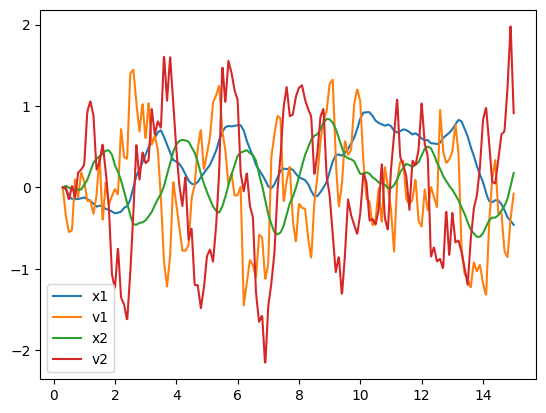

float32


In [3]:
solALIGN_32 = diffeqsolve(
    terms_hosc,
    align,
    t0_32,
    t1_32,
    dt0=dt0_32,
    y0=y0_hosc,
    args=args_hosc,
    saveat=saveat_32,
)
plot_sol(solALIGN_32, dim=2)
print(solALIGN_32.ys.dtype)

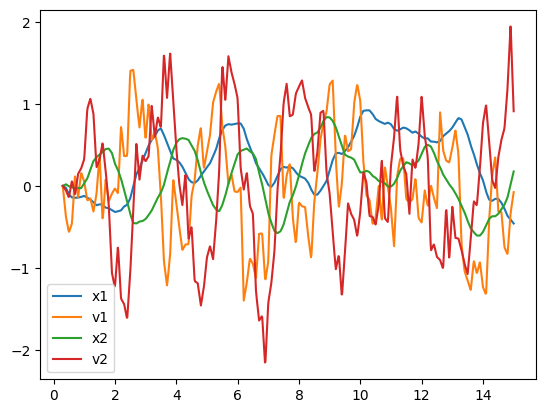

In [8]:
solALIGN = diffeqsolve(
    terms_hosc,
    align,
    t0,
    t1,
    dt0=dt0,
    y0=y0_hosc,
    args=args_hosc,
    saveat=saveat,
)
plot_sol(solALIGN, dim=2)
print(solALIGN.ys.dtype)

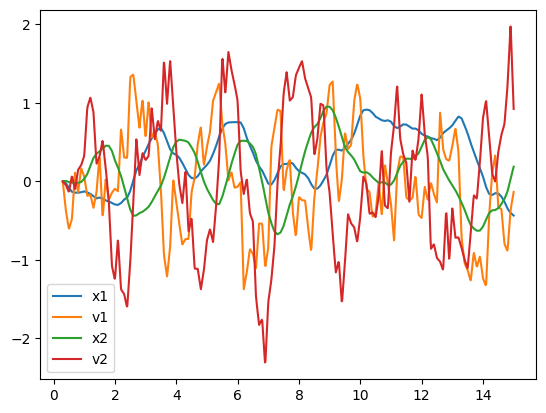

In [6]:
solShARK = diffeqsolve(
    terms_hosc, ShARK(), t0, t1, dt0=0.1, y0=y0_hosc, args=args_hosc, saveat=saveat
)
plot_sol(solShARK, dim=2)

In [11]:
print(solShARK.ys.dtype)

float64


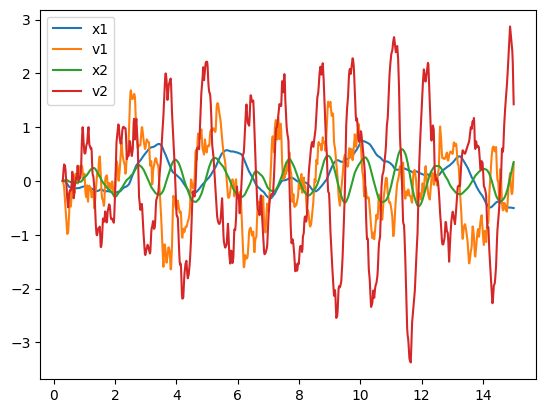

In [7]:
# ShARK adaptive
half_solver = HalfSolver(ShARK())
controller = PIDController(pcoeff=0.1, icoeff=0.3, rtol=0.005, atol=0.001)
solShARK_PID = diffeqsolve(
    terms_hosc,
    half_solver,
    t0,
    t1,
    dt0=0.1,
    y0=y0_hosc,
    args=args_hosc,
    saveat=saveat,
    stepsize_controller=controller,
)
plot_sol(solShARK_PID, dim=2)

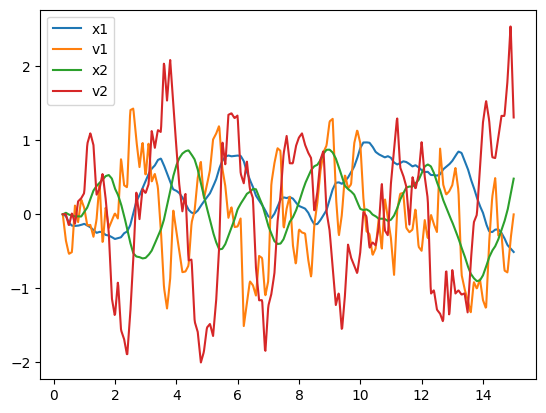

In [3]:
solSEA = diffeqsolve(
    terms_hosc, SEA(), t0, t1, dt0=0.1, y0=y0_hosc, args=args_hosc, saveat=saveat
)
plot_sol(solSEA, dim=2)

In [ ]:
solEuler = diffeqsolve(
    terms_hosc, Euler(), t0, t1, dt0=0.1, y0=y0_hosc, args=args_hosc, saveat=saveat
)
plot_sol(solEuler, dim=2)

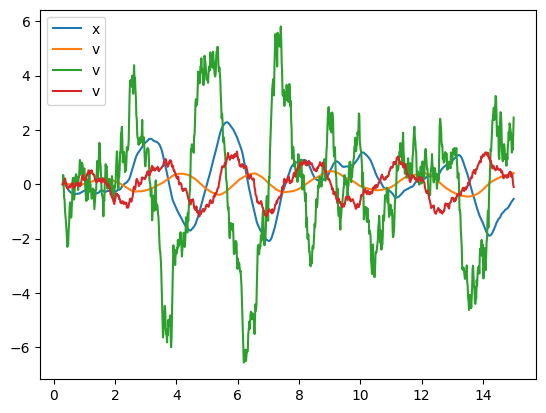

In [8]:
solPrecise = diffeqsolve(
    terms_hosc, Euler(), t0, t1, dt0=0.005, y0=y0_hosc, args=args_hosc, saveat=saveat
)
plot_sol(solPrecise, dim=2)

In [ ]:
stepsize_controller = PIDController(rtol=0.003, atol=0.001)
solALIGN_PID = diffeqsolve(
    terms_hosc,
    ALIGN(),
    t0,
    t1,
    dt0=1.0,
    y0=y0_hosc,
    args=args_hosc,
    saveat=saveat,
    stepsize_controller=stepsize_controller,
)
plot_sol(solALIGN_PID)

In [ ]:
print(f"Euler:    {solEuler.ys[-1]}")
print(f"SEA:      {solSEA.ys[-1]}")
print(f"ShARK:    {solShARK.ys[-1]}")
print(f"ALIGN     {solALIGN.ys[-1]}")
print(f"PID:      {solALIGN_PID.ys[-1]}")
print(f"Precise:  {solPrecise.ys[-1]}")